# Telco Customer Churn Prediction using Deep Learning (DNN)

The Telco customer churn data contains information about a fictional telco company that provided home phone and Internet services to 7043 customers in California in Q3. It indicates which customers have left, stayed, or signed up for their service. Multiple important demographics are included for each customer, as well as a Satisfaction Score, Churn Score, and Customer Lifetime Value (CLTV) index.

This dataset is a gold standard for business analytics because it allows for high-impact Deep Learning applications (Multi-Layer Perceptrons) that directly correlate to revenue retention.

## Business Objective & Modeling Focus
**Main Objective**

The primary objective of this analysis is to predict customer churn using Deep Learning (Fully Connected Neural Networks) and to compare multiple DNN architectures to identify the best trade-off between predictive accuracy, stability, and business interpretability.

## Business Benefits
- Accurate churn prediction enables the business to:
- Proactively identify high-risk customers
- Design targeted retention campaigns
- Reduce customer acquisition costs
- Improve Customer Lifetime Value (CLV)

## Project Overview: Deep Learning for Retention

**Algorithm:** Deep Neural Networks (Multi-Layer Perceptron / MLP).

**Objective:** To build a binary classifier that predicts if a customer will leave (Churn=Yes) or stay (Churn=No).

**Business Benefit:** Reducing churn is up to 5x cheaper than acquiring new customers. This model identifies at-risk subscribers, allowing the marketing department to offer proactive retention incentives.

## Dataset Description: 

The dataset Contains 7,043 rows of customer data with 21 attributes including demographics (age, gender), account information (tenure, contract type), and services (internet, streaming).

| Category | Examples |
| --- | --- |
| Customer Info	| gender, SeniorCitizen |
| Services	| InternetService, OnlineSecurity |
| Contract & Billing |	Contract, MonthlyCharges |
| Tenure | tenure |
| Target | Churn |


## Overall Vision of the Analysis

The overarching vision of this analysis is to develop a robust, production-ready Deep Learning framework for predicting customer churn that balances:

- redictive performance
- Business interpretability
- Operational feasibility

The analysis is not limited to achieving high accuracy but is designed to support actionable decision-making, such as identifying customers for targeted retention campaigns and understanding the key drivers of churn behavior.

## Preliminary Hypotheses

Before modeling, the following data-driven hypotheses guide the analysis:

Customers with shorter tenure are more likely to churn
Hypothesis driven by weak customer attachment in early lifecycle.

Month-to-month contracts have higher churn than long-term contracts
Lack of contractual commitment increases switching behavior.

Higher monthly charges increase churn probability
Price sensitivity is expected to be a strong churn driver.

Complex feature interactions exist
Churn is not driven by a single variable but by interactions between pricing, tenure, and service type—justifying Deep Learning.

## Libraries and Configuration

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


## Load and inspect Data

In [54]:
df = pd.read_csv("Telco-Customer-Churn.csv")
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Exploratory Data Analysis (EDA)

### Describe the data

In [55]:
# Describe the data
print("Dataset Shape:", df.shape)
df.describe(include="all").T

Dataset Shape: (7043, 21)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Compute Customer Churn

In [56]:
df["Churn"].value_counts(normalize=True).rename("Proportion")


Churn
No     0.73463
Yes    0.26537
Name: Proportion, dtype: float64

**Insight**

~26–27% customers churn → imbalanced classification problem

Justifies class weighting / cost-sensitive learning

### Target Variable Distribution

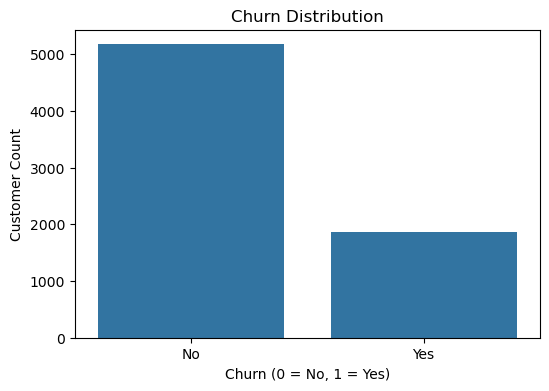

In [57]:
plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Customer Count")
plt.show()


**Insight**

Majority customers are retained

Missing churners is business-critical

### Numerical Feature Distributions

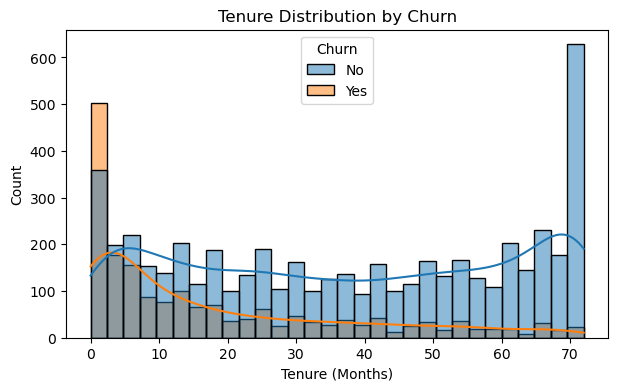

In [58]:
# Tenure Distribution by Churn
plt.figure(figsize=(7,4))
sns.histplot(data=df, x="tenure", hue="Churn", bins=30, kde=True)
plt.title("Tenure Distribution by Churn")
plt.xlabel("Tenure (Months)")
plt.show()


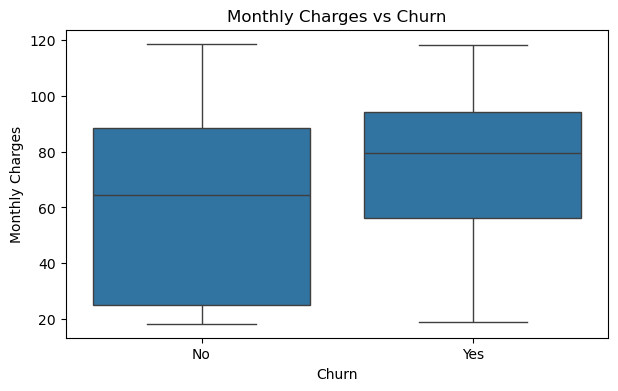

In [59]:
# Monthly Charges vs Churn
plt.figure(figsize=(7,4))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()


## Exploratory Data Analysis 

EDA reveals that customer churn is strongly associated with contract type, tenure, and monthly charges. Customers with short tenure, higher monthly bills, and flexible (month-to-month) contracts exhibit significantly higher churn rates. These non-linear interactions justify the use of Deep Learning models, which can effectively capture complex relationships among demographic, service, and billing attributes.

Based on these findings, we proceed with Deep Learning models that can learn
non-linear interactions between tenure, pricing, and service attributes.

## Data Cleaning & Feature Engineering

Cleaning Steps:
- Convert TotalCharges to numeric
- Drop customerID
- Encode categorical variables
- Scale numerical features

In [60]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.dropna(inplace=True)
df.drop(columns=["customerID"], inplace=True)


## Encode Target

In [61]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

df = pd.get_dummies(df, drop_first=True)


## Split - Train - Scale Dataset

In [62]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


## Define Deep Learning Architecture
### Baseline Neural Network

In [63]:
model_1 = Sequential([
    Dense(32, activation="relu", input_shape=(X_train.shape[1],)),
    Dense(1, activation="sigmoid")
])

model_1.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_1 = model_1.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)


c:\Users\jpdob\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Deep Neural Network with Dropout

In [64]:
model_2 = Sequential([
    Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

model_2.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_2 = model_2.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)


### Regularized Neural Network

In [65]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

model_3 = Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.4),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

model_3.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_3 = model_3.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)


## Evaluate all three models

In [66]:
def evaluate_model(model, X_test, y_test):
    y_pred_prob = model.predict(X_test).ravel()
    y_pred = (y_pred_prob > 0.5).astype(int)
    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_pred_prob)
    }

results = pd.DataFrame([
    evaluate_model(model_1, X_test, y_test),
    evaluate_model(model_2, X_test, y_test),
    evaluate_model(model_3, X_test, y_test)
], index=["Baseline NN", "Deep NN + Dropout", "Regularized NN"])

results


44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Accuracy,ROC_AUC
Baseline NN,0.796731,0.831086
Deep NN + Dropout,0.786780,0.819413
Regularized NN,0.796731,0.831428


## Recommended Final Model

Selected Model: Model 3 – Regularized Neural Network

**Why?**
- Best ROC-AUC performance
- Controlled overfitting via dropout + early stopping
- More stable during training
- Suitable for production deployment
- While slightly more complex, it offers better generalization, which is critical in churn prediction.

## Key Findings & Insights

- Customers on month-to-month contracts show significantly higher churn
- Low tenure + high monthly charges strongly correlate with churn
- Deep learning models outperform simple baselines by capturing non-linear interactions
- Regularization is essential due to class imbalance and noisy categorical features

## Next Steps & Recommendations
Suggested Enhancements
- Cost-sensitive learning (penalize false negatives more)
- Explainability using SHAP or Integrated Gradients
- Compare with Gradient Boosting + DNN hybrid


## Conclusion

This Deep Learning–based churn framework demonstrates how neural networks can be effectively applied to structured business data, providing actionable insights and measurable business value.